In [1]:
import torch, numpy, matplotlib
"""
Attention-Based Operator Learning for Chip Thermal Reconstruction
==================================================================

Paradigm:
  - Train across many (heat-source, thermal-field) pairs generated by FDM
  - Each training step: randomly sample K sensors from the field, train the
    network to reconstruct the full field from just those readings
  - At inference: user places any number of sensors anywhere → real-time
    full-field prediction

Architecture (~1.2M params, d_model=128):
  SensorEncoder  : (x, y, T) + Fourier features → d_model
  Self-attention : sensor set sees itself (permutation-invariant)
  QueryEncoder   : (x, y) + Fourier features → d_model
  Cross-attention: query attends to sensor set (variable K via mask)
  MLP head       : → T(x, y)

Why this is the right model class:
  - Set-invariant: sensor order and count don't matter (mask handles padding)
  - Continuous coordinates: Fourier features give spectral bias that suits
    smooth thermal fields without overfitting high frequencies
  - Separable train/inference cost: one expensive training, cheap inference
"""

"\nAttention-Based Operator Learning for Chip Thermal Reconstruction\n==================================================================\n\nParadigm:\n  - Train across many (heat-source, thermal-field) pairs generated by FDM\n  - Each training step: randomly sample K sensors from the field, train the\n    network to reconstruct the full field from just those readings\n  - At inference: user places any number of sensors anywhere → real-time\n    full-field prediction\n\nArchitecture (~1.2M params, d_model=128):\n  SensorEncoder  : (x, y, T) + Fourier features → d_model\n  Self-attention : sensor set sees itself (permutation-invariant)\n  QueryEncoder   : (x, y) + Fourier features → d_model\n  Cross-attention: query attends to sensor set (variable K via mask)\n  MLP head       : → T(x, y)\n\nWhy this is the right model class:\n  - Set-invariant: sensor order and count don't matter (mask handles padding)\n  - Continuous coordinates: Fourier features give spectral bias that suits\n    smoo

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import splu
import matplotlib.pyplot as plt
from dataclasses import dataclass
import time
# ═══════════════════════════════════════════════════════════════════════
# 1. Config
# ═══════════════════════════════════════════════════════════════════════
@dataclass
class Config:
    # Physics / geometry
    Lx: float = 1.0
    Ly: float = 1.0
    k:  float = 1.0       # thermal conductivity
    h:  float = 5.0       # effective convection coefficient
    T_amb: float = 25.0
    nx: int = 40
    ny: int = 40
    # Dataset
    n_train: int = 128
    n_val:   int = 32
    k_min:   int = 3
    k_max:   int = 12
    n_query: int = 384
    # Model
    d_model:   int = 128
    n_heads:   int = 4
    n_self:    int = 2
    n_cross:   int = 3
    n_fourier: int = 32
    fourier_sigma: float = 5.0
    # Training
    epochs: int = 20
    batch_size: int = 16
    lr: float = 1e-3
    weight_decay: float = 1e-5

CFG = Config()


In [11]:

# ═══════════════════════════════════════════════════════════════════════
# 2. FDM ground-truth solver (linear system; LU-factor once, solve many)
# ═══════════════════════════════════════════════════════════════════════
def build_fdm_system(cfg):
    nx, ny = cfg.nx, cfg.ny
    dx = cfg.Lx / (nx - 1)
    dy = cfg.Ly / (ny - 1)
    N = nx * ny
    A = lil_matrix((N, N))
    boundary = np.zeros(N, dtype=bool)
    for j in range(ny):
        for i in range(nx):
            idx = j * nx + i
            if i == 0 or i == nx - 1 or j == 0 or j == ny - 1:
                A[idx, idx] = 1.0
                boundary[idx] = True
            else:
                A[idx, idx]      = -2*cfg.k/dx**2 - 2*cfg.k/dy**2 - cfg.h
                A[idx, idx - 1]  = cfg.k / dx**2
                A[idx, idx + 1]  = cfg.k / dx**2
                A[idx, idx - nx] = cfg.k / dy**2
                A[idx, idx + nx] = cfg.k / dy**2
    return splu(csr_matrix(A).tocsc()), boundary

def solve_fdm(lu, boundary, Q, cfg):
    """k∇²T - h(T-T_amb) + Q = 0, Dirichlet T=T_amb on boundary."""
    N = cfg.nx * cfg.ny
    b = np.empty(N)
    Qf = Q.flatten()
    b[boundary] = cfg.T_amb
    b[~boundary] = -cfg.h * cfg.T_amb - Qf[~boundary]
    return lu.solve(b).reshape(cfg.ny, cfg.nx)

def random_heat_source(cfg):
    n_spots = np.random.randint(1, 5)
    x = np.linspace(0, cfg.Lx, cfg.nx)
    y = np.linspace(0, cfg.Ly, cfg.ny)
    X, Y = np.meshgrid(x, y)
    Q = np.zeros_like(X)
    for _ in range(n_spots):
        cx  = np.random.uniform(0.15, cfg.Lx - 0.15)
        cy  = np.random.uniform(0.15, cfg.Ly - 0.15)
        sig = np.random.uniform(0.05, 0.15)
        amp = np.random.uniform(100, 400)
        Q += amp * np.exp(-((X-cx)**2 + (Y-cy)**2) / (2*sig**2))
    return Q

def generate_dataset(n, lu, boundary, cfg, tag=''):
    Ts, Qs = [], []
    t0 = time.time()
    for i in range(n):
        Q = random_heat_source(cfg)
        T = solve_fdm(lu, boundary, Q, cfg)
        Ts.append(T.astype(np.float32))
        Qs.append(Q.astype(np.float32))
    print(f"  [{tag}] generated {n} scenarios in {time.time()-t0:.1f}s")
    return np.stack(Ts), np.stack(Qs)

# ═══════════════════════════════════════════════════════════════════════
# 3. Model
# ═══════════════════════════════════════════════════════════════════════
class FourierFeatures(nn.Module):
    """Random Fourier features: (x, y) → [sin(2π Bx), cos(2π Bx)]"""
    def __init__(self, input_dim=2, n_features=32, sigma=5.0):
        super().__init__()
        self.register_buffer('B', torch.randn(input_dim, n_features) * sigma)
    def forward(self, x):
        xB = 2 * np.pi * (x @ self.B)
        return torch.cat([torch.sin(xB), torch.cos(xB)], dim=-1)

class SensorEncoder(nn.Module):
    def __init__(self, d_model, n_fourier, sigma):
        super().__init__()
        self.ff = FourierFeatures(2, n_fourier, sigma)
        self.mlp = nn.Sequential(
            nn.Linear(2*n_fourier + 1, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )
    def forward(self, sensors):
        # sensors: (B, K, 3) = (x, y, T)
        xy = sensors[..., :2]
        T  = sensors[..., 2:3]
        return self.mlp(torch.cat([self.ff(xy), T], dim=-1))

class QueryEncoder(nn.Module):
    def __init__(self, d_model, n_fourier, sigma):
        super().__init__()
        self.ff = FourierFeatures(2, n_fourier, sigma)
        self.mlp = nn.Sequential(
            nn.Linear(2*n_fourier, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )
    def forward(self, q):
        return self.mlp(self.ff(q))

class AttentionBlock(nn.Module):
    """Pre-norm transformer block; self-attn if cross=False else cross-attn."""
    def __init__(self, d_model, n_heads, ff_mult=4, cross=False):
        super().__init__()
        self.cross = cross
        self.ln_q = nn.LayerNorm(d_model)
        self.ln_kv = nn.LayerNorm(d_model) if cross else None
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_mult*d_model),
            nn.GELU(),
            nn.Linear(ff_mult*d_model, d_model),
        )
    def forward(self, x, ctx=None, mask=None):
        q = self.ln_q(x)
        if self.cross:
            kv = self.ln_kv(ctx)
            a, _ = self.attn(q, kv, kv, key_padding_mask=mask)
        else:
            a, _ = self.attn(q, q, q, key_padding_mask=mask)
        x = x + a
        return x + self.ffn(self.ln2(x))

class ThermalOperator(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.sens_enc = SensorEncoder(cfg.d_model, cfg.n_fourier, cfg.fourier_sigma)
        self.query_enc = QueryEncoder(cfg.d_model, cfg.n_fourier, cfg.fourier_sigma)
        self.self_blocks  = nn.ModuleList([
            AttentionBlock(cfg.d_model, cfg.n_heads, cross=False)
            for _ in range(cfg.n_self)
        ])
        self.cross_blocks = nn.ModuleList([
            AttentionBlock(cfg.d_model, cfg.n_heads, cross=True)
            for _ in range(cfg.n_cross)
        ])
        self.head = nn.Sequential(
            nn.LayerNorm(cfg.d_model),
            nn.Linear(cfg.d_model, cfg.d_model),
            nn.GELU(),
            nn.Linear(cfg.d_model, 1),
        )
    def forward(self, sensors, queries, sensor_mask=None):
        s = self.sens_enc(sensors)
        for blk in self.self_blocks:
            s = blk(s, mask=sensor_mask)
        q = self.query_enc(queries)
        for blk in self.cross_blocks:
            q = blk(q, ctx=s, mask=sensor_mask)
        return self.head(q).squeeze(-1)   # (B, Q)

# ═══════════════════════════════════════════════════════════════════════
# 4. Dataset / collate
# ═══════════════════════════════════════════════════════════════════════
class ScenarioDataset(Dataset):
    def __init__(self, Ts, cfg, T_mean, T_std):
        self.Ts = Ts
        self.cfg = cfg
        self.T_mean = T_mean
        self.T_std  = T_std
        x = np.linspace(0, cfg.Lx, cfg.nx, dtype=np.float32)
        y = np.linspace(0, cfg.Ly, cfg.ny, dtype=np.float32)
        X, Y = np.meshgrid(x, y)
        self.X = X.flatten()
        self.Y = Y.flatten()
    def __len__(self):
        return len(self.Ts)
    def __getitem__(self, idx):
        T = self.Ts[idx].flatten()
        Tn = (T - self.T_mean) / self.T_std
        N = len(T)
        K = np.random.randint(self.cfg.k_min, self.cfg.k_max + 1)
        sidx = np.random.choice(N, K, replace=False)
        sensors = np.stack([self.X[sidx], self.Y[sidx], Tn[sidx]], axis=-1).astype(np.float32)
        qidx = np.random.choice(N, self.cfg.n_query, replace=False)
        queries = np.stack([self.X[qidx], self.Y[qidx]], axis=-1).astype(np.float32)
        qT = Tn[qidx].astype(np.float32)
        return torch.from_numpy(sensors), torch.from_numpy(queries), torch.from_numpy(qT)

def collate(batch):
    max_K = max(s.shape[0] for s, _, _ in batch)
    B = len(batch)
    sens = torch.zeros(B, max_K, 3)
    mask = torch.ones(B, max_K, dtype=torch.bool)   # True = pad position
    for i, (s, _, _) in enumerate(batch):
        K = s.shape[0]
        sens[i, :K] = s
        mask[i, :K] = False
    queries = torch.stack([q for _, q, _ in batch])
    qT = torch.stack([t for _, _, t in batch])
    return sens, queries, qT, mask

# ═══════════════════════════════════════════════════════════════════════
# 5. Training
# ═══════════════════════════════════════════════════════════════════════
def train_model(model, train_loader, val_loader, cfg, device):
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs)
    hist = {'train': [], 'val': []}
    for ep in range(cfg.epochs):
        model.train()
        tot, n = 0.0, 0
        for s, q, t, m in train_loader:
            s, q, t, m = s.to(device), q.to(device), t.to(device), m.to(device)
            pred = model(s, q, sensor_mask=m)
            loss = F.mse_loss(pred, t)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot += loss.item() * t.numel(); n += t.numel()
        tr = tot / n

        model.eval()
        tot, n = 0.0, 0
        with torch.no_grad():
            for s, q, t, m in val_loader:
                s, q, t, m = s.to(device), q.to(device), t.to(device), m.to(device)
                pred = model(s, q, sensor_mask=m)
                tot += F.mse_loss(pred, t).item() * t.numel(); n += t.numel()
        v = tot / n

        sched.step()
        hist['train'].append(tr); hist['val'].append(v)
        print(f"  Ep {ep+1:02d}/{cfg.epochs}  train {tr:.5f}  val {v:.5f}")
    return hist

# ═══════════════════════════════════════════════════════════════════════
# 6. Inference helper
# ═══════════════════════════════════════════════════════════════════════
@torch.no_grad()
def predict_field(model, T_true, K, cfg, T_mean, T_std, device, seed=None):
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()
    nx, ny = cfg.nx, cfg.ny
    x = np.linspace(0, cfg.Lx, nx, dtype=np.float32)
    y = np.linspace(0, cfg.Ly, ny, dtype=np.float32)
    X, Y = np.meshgrid(x, y)
    Xf, Yf = X.flatten(), Y.flatten()
    Tn = (T_true.flatten() - T_mean) / T_std
    N = len(Tn)
    sidx = rng.choice(N, K, replace=False)
    sensors = torch.from_numpy(
        np.stack([Xf[sidx], Yf[sidx], Tn[sidx]], axis=-1).astype(np.float32)
    ).unsqueeze(0).to(device)
    queries = torch.from_numpy(
        np.stack([Xf, Yf], axis=-1).astype(np.float32)
    ).unsqueeze(0).to(device)
    model.eval()
    pred_n = model(sensors, queries).cpu().numpy()[0]
    pred = pred_n * T_std + T_mean
    return pred.reshape(ny, nx), (Xf[sidx], Yf[sidx], T_true.flatten()[sidx])

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# 7. Main
# ═══════════════════════════════════════════════════════════════════════
if __name__ == '__main__':
    torch.manual_seed(42); np.random.seed(42)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device: {device}\n")

    print("[1/5] Building FDM system ...")
    lu, boundary = build_fdm_system(CFG)

    print("\n[2/5] Generating scenarios ...")
    Ts_tr, Qs_tr = generate_dataset(CFG.n_train, lu, boundary, CFG, tag='train')
    Ts_va, Qs_va = generate_dataset(CFG.n_val,   lu, boundary, CFG, tag='val')
    T_mean = float(Ts_tr.mean()); T_std = float(Ts_tr.std())
    print(f"  normalization: T_mean={T_mean:.2f}  T_std={T_std:.2f}")

    train_ds = ScenarioDataset(Ts_tr, CFG, T_mean, T_std)
    val_ds   = ScenarioDataset(Ts_va, CFG, T_mean, T_std)
    train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,  collate_fn=collate)
    val_loader   = DataLoader(val_ds,   batch_size=CFG.batch_size, shuffle=False, collate_fn=collate)

    print("\n[3/5] Model ...")
    model = ThermalOperator(CFG).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  parameters: {n_params:,}")

    exit
    print("\n[4/5] Training ...")
    hist = train_model(model, train_loader, val_loader, CFG, device)

    print("\n[5/5] Evaluating on a fresh test scenario with varying K ...")
    np.random.seed(777)
    Q_test = random_heat_source(CFG)
    T_test = solve_fdm(lu, boundary, Q_test, CFG).astype(np.float32)

    # --- scaling curve: RMSE vs K across multiple test scenarios ---
    print("  [scaling curve] ...")
    Ks = [3, 4, 5, 6, 8, 10, 12, 15, 20, 30]
    n_trials_per_K = 8
    scaling = {K: [] for K in Ks}
    # 10 fresh test scenarios
    test_scenarios = []
    for _ in range(10):
        Qt = random_heat_source(CFG)
        Tt = solve_fdm(lu, boundary, Qt, CFG).astype(np.float32)
        test_scenarios.append(Tt)
    for K in Ks:
        for Tt in test_scenarios:
            for trial in range(n_trials_per_K):
                pred, _ = predict_field(model, Tt, K, CFG, T_mean, T_std, device)
                scaling[K].append(float(np.sqrt(((pred - Tt)**2).mean())))

    # --- main figure ---
    Ks_show = [3, 5, 8, 15]
    fig, axes = plt.subplots(2, len(Ks_show) + 1, figsize=(4*(len(Ks_show)+1), 7.8))
    vmin, vmax = T_test.min(), T_test.max()

    ax = axes[0, 0]
    im = ax.imshow(T_test, extent=[0, CFG.Lx, 0, CFG.Ly], origin='lower',
                   cmap='hot', vmin=vmin, vmax=vmax)
    ax.set_title('(a) FDM truth\n(simulates IR camera)', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, label='T (°C)')

    ax = axes[1, 0]
    means = [np.mean(scaling[K]) for K in Ks]
    stds  = [np.std(scaling[K])  for K in Ks]
    ax.errorbar(Ks, means, yerr=stds, marker='o', capsize=3, lw=1.5)
    ax.set_xlabel('K (number of sensors)')
    ax.set_ylabel('RMSE (°C)')
    ax.set_title('RMSE vs sensor count\n(10 scenarios × 8 trials each)', fontsize=11)
    ax.set_xscale('log'); ax.grid(alpha=0.3, which='both')

    for i, K in enumerate(Ks_show):
        pred, (sx, sy, st) = predict_field(model, T_test, K, CFG, T_mean, T_std, device, seed=i+1)
        err = np.abs(pred - T_test)
        rmse = float(np.sqrt(((pred - T_test)**2).mean()))
        mae  = float(err.mean())

        ax = axes[0, i+1]
        im = ax.imshow(pred, extent=[0, CFG.Lx, 0, CFG.Ly], origin='lower',
                       cmap='hot', vmin=vmin, vmax=vmax)
        ax.scatter(sx, sy, c='cyan', s=50, edgecolors='white', linewidths=1.2, zorder=5)
        ax.set_title(f'K={K} sensors\nRMSE={rmse:.2f}°C', fontsize=11)
        ax.set_xlabel('x')
        plt.colorbar(im, ax=ax, fraction=0.046, label='T (°C)')

        ax = axes[1, i+1]
        im = ax.imshow(err, extent=[0, CFG.Lx, 0, CFG.Ly], origin='lower', cmap='YlOrRd')
        ax.scatter(sx, sy, c='blue', s=35, marker='^', edgecolors='white', linewidths=0.6, zorder=5)
        ax.set_title(f'|Error|   MAE={mae:.2f}°C  Max={err.max():.2f}°C', fontsize=10)
        ax.set_xlabel('x')
        plt.colorbar(im, ax=ax, fraction=0.046, label='|ΔT| (°C)')

    plt.suptitle(
        'Attention-based thermal operator  |  one trained model, arbitrary sensor count at inference',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    out = 'chip_thermal_attention_result.png'
    plt.savefig(out, dpi=130, bbox_inches='tight')
    print(f"\nSaved figure: {out}")

Device: cpu

[1/5] Building FDM system ...

[2/5] Generating scenarios ...
  [train] generated 128 scenarios in 0.0s
  [val] generated 32 scenarios in 0.0s
  normalization: T_mean=26.40  T_std=1.79

[3/5] Model ...
  parameters: 1,058,817

[4/5] Training ...


NameError: name 'train_model' is not defined

In [13]:
from dataclasses import asdict

device = torch.device("mps" if torch.mps.is_available() else "cpu")
ckpt = torch.load("thermal_operator.pt", map_location=device, weights_only=False)
CFG_loaded = Config(**ckpt['config'])
T_mean = ckpt['T_mean']
T_std  = ckpt['T_std']

model = ThermalOperator(CFG_loaded).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print('Loaded.')

Loaded.


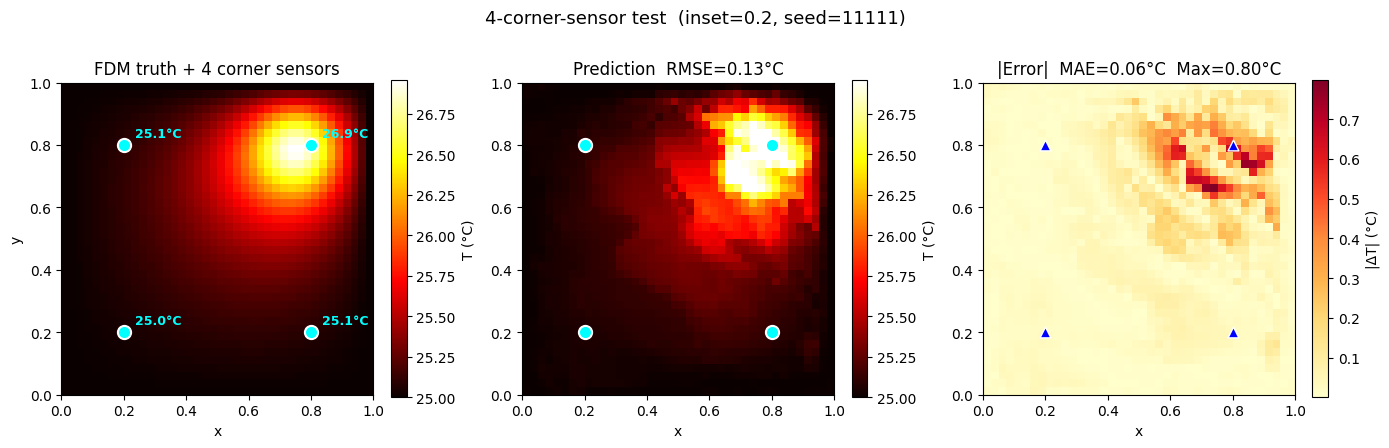

Corner readings      : [25.049999237060547, 25.09000015258789, 25.110000610351562, 26.8700008392334] °C
Truth field range    : [25.00, 26.96] °C
Prediction RMSE/MAE  : 0.127 / 0.063 °C    Max|err|: 0.799 °C


(array([[25.      , 25.      , 25.      , ..., 25.      , 25.      ,
         25.      ],
        [25.      , 25.000683, 25.001366, ..., 25.002838, 25.001429,
         25.      ],
        [25.      , 25.001366, 25.002733, ..., 25.005724, 25.002882,
         25.      ],
        ...,
        [25.      , 25.00327 , 25.006598, ..., 25.163113, 25.080982,
         25.      ],
        [25.      , 25.001646, 25.003323, ..., 25.082325, 25.040894,
         25.      ],
        [25.      , 25.      , 25.      , ..., 25.      , 25.      ,
         25.      ]], shape=(40, 40), dtype=float32),
 array([[25.013525, 24.989399, 24.999191, ..., 25.007843, 25.011011,
         25.016647],
        [25.001263, 24.98522 , 25.01579 , ..., 24.99556 , 25.001707,
         25.01133 ],
        [24.991428, 25.002607, 25.034735, ..., 25.020956, 24.996956,
         25.006193],
        ...,
        [25.013588, 25.007095, 25.005564, ..., 25.0634  , 25.009813,
         24.985123],
        [25.025053, 25.016361, 25.01363 ,

In [18]:
# ═══════════════════════════════════════════════════════════════════════
# Test: 4 sensors at rectangle corners
# ═══════════════════════════════════════════════════════════════════════
@torch.no_grad()
def test_corner_sensors(model, lu, boundary, cfg, T_mean, T_std, device,
                        inset=0.2, seed=11111, save_path='corner_test.png'):
    """
    Test the model with exactly 4 sensors at the rectangle corners.

    NOTE: sensors placed exactly at (0,0), (1,0), (0,1), (1,1) would lie on
    the Dirichlet boundary (T=T_amb by construction), giving trivial readings.
    Default inset=0.05 samples the interior. Pass inset=0.0 for literal corners.
    """
    # Fresh test scenario (seeded so it's reproducible but not in training set)
    np.random.seed(seed)
    Q_test = random_heat_source(cfg)
    T_test = solve_fdm(lu, boundary, Q_test, cfg).astype(np.float32)

    # 4 corner positions
    corners = np.array([
        [0.0 + inset,       0.0 + inset      ],  # bottom-left
        [cfg.Lx - inset,    0.0 + inset      ],  # bottom-right
        [0.0 + inset,       cfg.Ly - inset   ],  # top-left
        [cfg.Lx - inset,    cfg.Ly - inset   ],  # top-right
    ], dtype=np.float32)

    # Read corner temps from ground truth (nearest grid point)
    xg = np.linspace(0, cfg.Lx, cfg.nx)
    yg = np.linspace(0, cfg.Ly, cfg.ny)
    sT = np.array([
        T_test[int(np.argmin(np.abs(yg - sy))),
               int(np.argmin(np.abs(xg - sx)))]
        for sx, sy in corners
    ], dtype=np.float32)

    # Pack input for model
    sT_norm = (sT - T_mean) / T_std
    sensors = torch.from_numpy(
        np.concatenate([corners, sT_norm[:, None]], axis=-1)
    ).unsqueeze(0).to(device)                                  # (1, 4, 3)

    X, Y = np.meshgrid(xg.astype(np.float32), yg.astype(np.float32))
    queries = torch.from_numpy(
        np.stack([X.flatten(), Y.flatten()], axis=-1)
    ).unsqueeze(0).to(device)                                  # (1, nx*ny, 2)

    model.eval()
    pred = (model(sensors, queries).cpu().numpy()[0] * T_std + T_mean).reshape(cfg.ny, cfg.nx)
    err = np.abs(pred - T_test)
    rmse = float(np.sqrt(((pred - T_test) ** 2).mean()))

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
    vmin, vmax = T_test.min(), T_test.max()

    ax = axes[0]
    im = ax.imshow(T_test, extent=[0, cfg.Lx, 0, cfg.Ly], origin='lower',
                   cmap='hot', vmin=vmin, vmax=vmax)
    ax.scatter(corners[:, 0], corners[:, 1], c='cyan', s=90,
               edgecolors='white', linewidths=1.5, zorder=5)
    for (sx, sy), t in zip(corners, sT):
        ax.annotate(f'{t:.1f}°C', (sx, sy), textcoords='offset points',
                    xytext=(8, 6), fontsize=9, color='cyan', fontweight='bold')
    ax.set_title('FDM truth + 4 corner sensors'); ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, label='T (°C)')

    ax = axes[1]
    im = ax.imshow(pred, extent=[0, cfg.Lx, 0, cfg.Ly], origin='lower',
                   cmap='hot', vmin=vmin, vmax=vmax)
    ax.scatter(corners[:, 0], corners[:, 1], c='cyan', s=90,
               edgecolors='white', linewidths=1.5, zorder=5)
    ax.set_title(f'Prediction  RMSE={rmse:.2f}°C'); ax.set_xlabel('x')
    plt.colorbar(im, ax=ax, fraction=0.046, label='T (°C)')

    ax = axes[2]
    im = ax.imshow(err, extent=[0, cfg.Lx, 0, cfg.Ly], origin='lower', cmap='YlOrRd')
    ax.scatter(corners[:, 0], corners[:, 1], c='blue', s=60, marker='^',
               edgecolors='white', linewidths=1, zorder=5)
    ax.set_title(f'|Error|  MAE={err.mean():.2f}°C  Max={err.max():.2f}°C')
    ax.set_xlabel('x')
    plt.colorbar(im, ax=ax, fraction=0.046, label='|ΔT| (°C)')

    plt.suptitle(f'4-corner-sensor test  (inset={inset}, seed={seed})', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()

    print(f'Corner readings      : {sT.round(2).tolist()} °C')
    print(f'Truth field range    : [{T_test.min():.2f}, {T_test.max():.2f}] °C')
    print(f'Prediction RMSE/MAE  : {rmse:.3f} / {err.mean():.3f} °C    Max|err|: {err.max():.3f} °C')
    return T_test, pred

# Call it
test_corner_sensors(model, lu, boundary, CFG, T_mean, T_std, device)


── Admissibility Report ──────────────────────────────
  Reconstruction RMSE       : 1.006 °C
  Residual scale (reference): 12.17
  FD residual on PREDICTION :
    RMSE abs  : 407.083   rel : 3343.8%
    Max abs   : 2487.612
  FD residual on FDM truth  :
    RMSE abs  : 0.004   (discretization-only floor)
  Autograd residual on prediction :
    RMSE abs  : 2558.355   rel : 21014.3%
    Max abs   : 55770.531


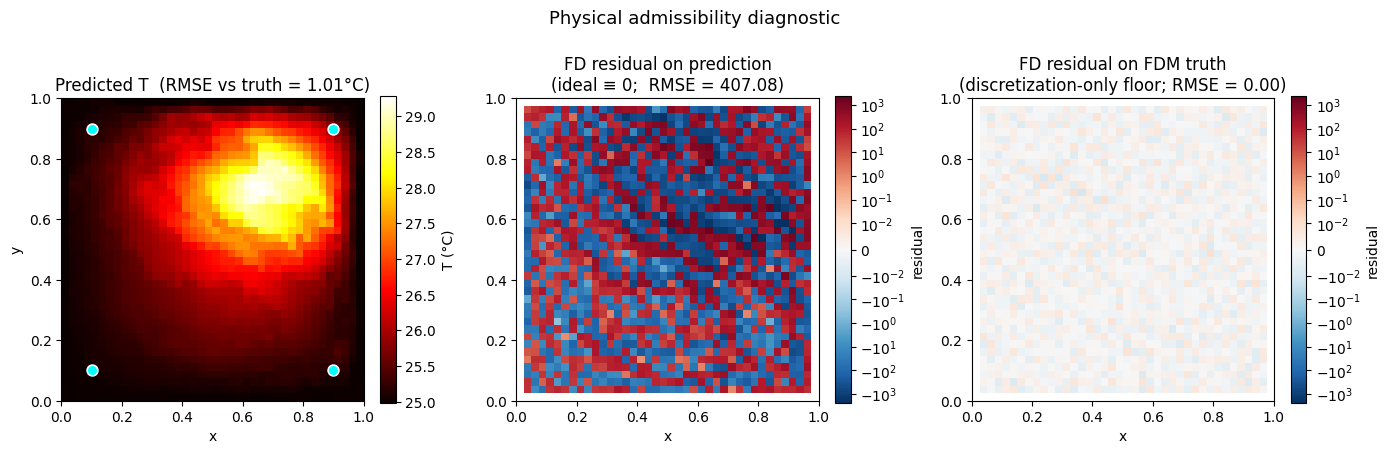

{'fd': {'rmse_abs': 407.08328875340817,
  'rmse_rel': 33.43778919862824,
  'max_abs': 2487.611606042497,
  'fdm_baseline': 0.0037226502565087466},
 'autograd': {'rmse_abs': 2558.355224609375,
  'rmse_rel': 210.1430961650628,
  'max_abs': 55770.53125},
 'recon_rmse': 1.00601065158844}

In [21]:
from matplotlib.colors import SymLogNorm
# ═══════════════════════════════════════════════════════════════════════
# Physical admissibility diagnostics
# ═══════════════════════════════════════════════════════════════════════
def fd_laplacian(T, dx, dy):
    """5-point stencil Laplacian. Returns NaN on 1-cell border."""
    L = np.full_like(T, np.nan, dtype=np.float64)
    L[1:-1, 1:-1] = (
        (T[1:-1, 2:] - 2*T[1:-1, 1:-1] + T[1:-1, :-2]) / dx**2 +
        (T[2:, 1:-1] - 2*T[1:-1, 1:-1] + T[:-2, 1:-1]) / dy**2
    )
    return L

def pde_residual_fd(T, Q, cfg):
    """residual = k·∇²T − h·(T − T_amb) + Q ;  ideal ≡ 0."""
    dx = cfg.Lx / (cfg.nx - 1)
    dy = cfg.Ly / (cfg.ny - 1)
    return cfg.k * fd_laplacian(T, dx, dy) - cfg.h * (T - cfg.T_amb) + Q


def pde_residual_autograd(model, cfg, T_mean, T_std, Q_grid, device, n_points=2000):
    """
    Evaluate residual at random interior points using autograd through the model.
    Catches high-frequency artifacts the grid-based FD check misses.
    Q_grid is the (ny, nx) ground-truth source; we bilinearly sample it at the query points.
    """
    model.eval()
    # Random interior points (avoid the boundary band where Dirichlet dominates)
    margin = 0.05
    xs = np.random.uniform(margin, cfg.Lx - margin, n_points).astype(np.float32)
    ys = np.random.uniform(margin, cfg.Ly - margin, n_points).astype(np.float32)

    # Bilinear-sample Q at these points
    gx = xs / cfg.Lx * (cfg.nx - 1)
    gy = ys / cfg.Ly * (cfg.ny - 1)
    i0, j0 = np.floor(gx).astype(int), np.floor(gy).astype(int)
    i1, j1 = np.clip(i0 + 1, 0, cfg.nx - 1), np.clip(j0 + 1, 0, cfg.ny - 1)
    fx, fy = gx - i0, gy - j0
    Q_at = ((1-fx)*(1-fy)*Q_grid[j0, i0] + fx*(1-fy)*Q_grid[j0, i1]
          + (1-fx)*fy     *Q_grid[j1, i0] + fx*fy     *Q_grid[j1, i1])

    # Build sensor input — use the same corner placement as your test, or any fixed config.
    # Caller should pass sensors in externally; here we just expect it via closure.
    raise NotImplementedError("Wrap this in evaluate_admissibility() below.")


def evaluate_admissibility(model, sensors_xyT, Q_true, T_true, cfg,
                           T_mean, T_std, device, n_autograd_points=2000):
    """
    Full admissibility report for a single scenario.

    sensors_xyT : (K, 3) numpy array of (x, y, T) in °C
    Q_true      : (ny, nx) numpy array of heat source density
    T_true      : (ny, nx) numpy array of FDM ground truth (for comparison)
    """
    # ── 1. Predict full field on the grid ──────────────────────────────
    x = np.linspace(0, cfg.Lx, cfg.nx, dtype=np.float32)
    y = np.linspace(0, cfg.Ly, cfg.ny, dtype=np.float32)
    X, Y = np.meshgrid(x, y)

    sT_norm = (sensors_xyT[:, 2] - T_mean) / T_std
    sensors = torch.from_numpy(
        np.concatenate([sensors_xyT[:, :2], sT_norm[:, None]], axis=-1).astype(np.float32)
    ).unsqueeze(0).to(device)
    queries_grid = torch.from_numpy(
        np.stack([X.flatten(), Y.flatten()], axis=-1)
    ).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        T_pred = (model(sensors, queries_grid).cpu().numpy()[0] * T_std + T_mean).reshape(cfg.ny, cfg.nx)

    # ── 2. Grid-based FD residual ──────────────────────────────────────
    R_pred = pde_residual_fd(T_pred, Q_true, cfg)
    R_true = pde_residual_fd(T_true, Q_true, cfg)       # reference: FDM's own discretization error
    interior = ~np.isnan(R_pred)

    # Normalize by the dominant term magnitude for a scale-free metric
    scale = np.abs(cfg.h * (T_true - cfg.T_amb) + Q_true)[interior].mean()

    fd_metrics = {
        'rmse_abs':     float(np.sqrt(np.mean(R_pred[interior]**2))),
        'rmse_rel':     float(np.sqrt(np.mean(R_pred[interior]**2)) / scale),
        'max_abs':      float(np.max(np.abs(R_pred[interior]))),
        'fdm_baseline': float(np.sqrt(np.mean(R_true[interior]**2))),
    }

    # ── 3. Autograd residual at random interior points ─────────────────
    margin = 0.05
    n = n_autograd_points
    xs = np.random.uniform(margin, cfg.Lx - margin, n).astype(np.float32)
    ys = np.random.uniform(margin, cfg.Ly - margin, n).astype(np.float32)

    gx = xs / cfg.Lx * (cfg.nx - 1); gy = ys / cfg.Ly * (cfg.ny - 1)
    i0 = np.clip(np.floor(gx).astype(int), 0, cfg.nx - 2)
    j0 = np.clip(np.floor(gy).astype(int), 0, cfg.ny - 2)
    fx, fy = gx - i0, gy - j0
    Q_at = ((1-fx)*(1-fy)*Q_true[j0, i0] + fx*(1-fy)*Q_true[j0, i0+1]
          + (1-fx)*fy    *Q_true[j0+1, i0] + fx*fy    *Q_true[j0+1, i0+1])

    q = torch.tensor(np.stack([xs, ys], -1), device=device, requires_grad=True)
    q_batch = q.unsqueeze(0)                                    # (1, n, 2)
    T_q = model(sensors, q_batch).squeeze(0) * T_std + T_mean   # (n,) in °C

    grad1 = torch.autograd.grad(T_q.sum(), q, create_graph=True)[0]     # (n, 2)
    Tx, Ty = grad1[:, 0], grad1[:, 1]
    Txx = torch.autograd.grad(Tx.sum(), q, create_graph=True)[0][:, 0]
    Tyy = torch.autograd.grad(Ty.sum(), q, create_graph=True)[0][:, 1]
    lap = Txx + Tyy

    Q_tensor = torch.tensor(Q_at, device=device, dtype=T_q.dtype)
    R_ag = (cfg.k * lap - cfg.h * (T_q - cfg.T_amb) + Q_tensor).detach().cpu().numpy()

    ag_metrics = {
        'rmse_abs': float(np.sqrt(np.mean(R_ag**2))),
        'rmse_rel': float(np.sqrt(np.mean(R_ag**2)) / scale),
        'max_abs':  float(np.max(np.abs(R_ag))),
    }

    # ── 4. Report ──────────────────────────────────────────────────────
    recon_rmse = float(np.sqrt(np.mean((T_pred - T_true)**2)))
    print(f"\n── Admissibility Report ──────────────────────────────")
    print(f"  Reconstruction RMSE       : {recon_rmse:.3f} °C")
    print(f"  Residual scale (reference): {scale:.2f}")
    print(f"  FD residual on PREDICTION :")
    print(f"    RMSE abs  : {fd_metrics['rmse_abs']:.3f}   rel : {fd_metrics['rmse_rel']*100:.1f}%")
    print(f"    Max abs   : {fd_metrics['max_abs']:.3f}")
    print(f"  FD residual on FDM truth  :")
    print(f"    RMSE abs  : {fd_metrics['fdm_baseline']:.3f}   (discretization-only floor)")
    print(f"  Autograd residual on prediction :")
    print(f"    RMSE abs  : {ag_metrics['rmse_abs']:.3f}   rel : {ag_metrics['rmse_rel']*100:.1f}%")
    print(f"    Max abs   : {ag_metrics['max_abs']:.3f}")

    # ── 5. Visualize ───────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
    vmax = np.nanmax(np.abs(R_pred))

    ax = axes[0]
    im = ax.imshow(T_pred, extent=[0, cfg.Lx, 0, cfg.Ly], origin='lower', cmap='hot')
    ax.scatter(sensors_xyT[:, 0], sensors_xyT[:, 1], c='cyan', s=60,
               edgecolors='white', linewidths=1.2)
    ax.set_title(f'Predicted T  (RMSE vs truth = {recon_rmse:.2f}°C)'); ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, label='T (°C)')

    norm = SymLogNorm(linthresh=0.01, linscale=1, vmin=-vmax, vmax=vmax, base=10)
    ax = axes[1]
    im = ax.imshow(R_pred, extent=[0, cfg.Lx, 0, cfg.Ly], origin='lower',
                   cmap='RdBu_r', norm=norm)
    ax.set_title(f'FD residual on prediction\n(ideal ≡ 0;  RMSE = {fd_metrics["rmse_abs"]:.2f})')
    ax.set_xlabel('x')
    plt.colorbar(im, ax=ax, fraction=0.046, label='residual')

    ax = axes[2]
    vmax2 = np.nanmax(np.abs(R_true[interior]))
    im = ax.imshow(R_true, extent=[0, cfg.Lx, 0, cfg.Ly], origin='lower',
                   cmap='RdBu_r', norm=norm)
    ax.set_title(f'FD residual on FDM truth\n(discretization-only floor; RMSE = {fd_metrics["fdm_baseline"]:.2f})')
    ax.set_xlabel('x')
    plt.colorbar(im, ax=ax, fraction=0.046, label='residual')

    plt.suptitle('Physical admissibility diagnostic', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('admissibility.png', dpi=130, bbox_inches='tight')
    plt.show()

    return {'fd': fd_metrics, 'autograd': ag_metrics, 'recon_rmse': recon_rmse}


# ─── Run it on the 4-corner scenario ────────────────────────────────────
np.random.seed(11111)
Q_test = random_heat_source(CFG)
T_test = solve_fdm(lu, boundary, Q_test, CFG).astype(np.float32)

inset = 0.10
corners = np.array([
    [inset,         inset        ],
    [CFG.Lx-inset,  inset        ],
    [inset,         CFG.Ly-inset ],
    [CFG.Lx-inset,  CFG.Ly-inset ],
], dtype=np.float32)
xg = np.linspace(0, CFG.Lx, CFG.nx); yg = np.linspace(0, CFG.Ly, CFG.ny)
sT = np.array([T_test[int(np.argmin(np.abs(yg-sy))), int(np.argmin(np.abs(xg-sx)))]
               for sx, sy in corners], dtype=np.float32)
sensors_xyT = np.concatenate([corners, sT[:, None]], axis=-1)

evaluate_admissibility(model, sensors_xyT, Q_test, T_test, CFG, T_mean, T_std, device)